In [1]:
import argparse
import os
import re

import torch.nn.functional as F

os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
os.environ["TRANSFORMERS_NO_COMPILE"] = "1"
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from safetensors.torch import load_file as load_safetensors
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, balanced_accuracy_score,
                             calinski_harabasz_score, classification_report,
                             davies_bouldin_score, pairwise_distances,
                             silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import umap
import glob
from scipy.stats import spearmanr
import json


In [3]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct"]#, "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


output_dir = "/data/erblina/Master_thesis"

datasets_list = ["walledai/AdvBench","walledai/DTStereotype", "walledai/CatHarmfulQA","walledai/DTToxicity","truthfulqa/truthful_qa"]


model_steering_1 = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 1.6, 1.6, 1.6], 'alphas_down': [ -1.8, -2.0, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0, 2.0], 'alphas_down': [ -0.6, -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.11', 'model.layers.12'], 'alphas_up': [ 1.5, 1.1, 1.0], 'alphas_down': [-0.3, -0.25, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13', 'model.layers.14'], 'alphas_up': [ 2.0, 1.6, 2.0], 'alphas_down': [ -0.8, -0.5, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7', 'model.layers.13'], 'alphas_up': [ 1.2, 1.3, 1.4], 'alphas_down': [ -2.0, -1.8, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
    'meta-llama/Llama-3.2-3B': {'layers': [ 'model.layers.12', 'model.layers.10', 'model.layers.11'], 'alphas_up': [ 0.7, 1.0, 1.0], 'alphas_down': [ -2.0, -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
        }

In [4]:
def load_harmbench(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    hidden_states = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"hidden_states_pure.safetensors"))
    
    side = 'toxic'
    # # Define path pattern
    # pattern = f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_*.npy"

    # # Find all matching files
    # files = sorted(glob.glob(pattern))

    # # Load them into a dictionary keyed by alpha
    # data = {}
    # for file in files:
    #     # Extract the alpha value from filename
    #     alpha_str = os.path.splitext(os.path.basename(file))[0].split('_alpha_')[-1]
    #     alpha = float(alpha_str)
    #     data[alpha] = np.load(file, allow_pickle=True).item()

    return hidden_states, labels #, data

def load_datasets(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_hidden_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    return hidden_states_data, labels_data

def load_steering_dataset(model, dataset, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after_dataset = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_dataset_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after_dataset,
            alpha_d : labels_after_dataset_d
        }

    return data

def load_steering_harmbench(model, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after,
            alpha_d : labels_after_d
        }

    return data


def get_perplexity(perplexities, alpha, layer_name):
    """alpha can be float or str, layer_idx is an int."""
    alpha_str = str(alpha)
    for entry in perplexities[alpha_str]:
        if entry["layer_name"] == layer_name:
            return entry["perplexity"]
    raise ValueError(f"Layer {layer_name} not found for alpha {alpha}")

def get_perplexity_other(perplexities, layer_name):
    """layer_name is a str."""
    for entry in perplexities:
        if entry["layer_name"] == layer_name:
            return entry["perplexity"]
    raise ValueError(f"Layer {layer_name} not found.")

In [5]:
       
model_steering_final = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20'], 'alphas_up': [ 1.6, 1.6], 'alphas_down': [ -1.8, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
        'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0], 'alphas_down': [ -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
        'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
        'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
        'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.12'], 'alphas_up': [ 1.5, 1.0], 'alphas_down': [-0.3, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
        'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13'], 'alphas_up': [  2.0, 1.6], 'alphas_down': [ -0.8, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
        'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7'], 'alphas_up': [ 1.2, 1.3], 'alphas_down': [ -2.0, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
        'meta-llama/Llama-3.2-3B': {'layers': ['model.layers.10', 'model.layers.11'], 'alphas_up': [ 1.0, 1.0], 'alphas_down': [  -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
            }


model_steering_last_final = {'Qwen/Qwen2.5-3B': {'layers': ['model.layers.19', 'model.layers.20'], 'alphas_up': [2.2,1.6], 'alphas_down': [-2.5,  -2.0], 'max_avg_tox': [0.82, 0.76, 0.785], 'min_avg_tox': [0.265, 0.265, 0.295]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.22'], 'alphas_up': [2.0, 2.0], 'alphas_down': [-0.9, -0.8], 'max_avg_tox': [0.68, 0.645, 0.645], 'min_avg_tox': [0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': ['model.layers.9', 'model.layers.8', 'model.layers.7'], 'alphas_up': [1.8, 2.0, 2.0], 'alphas_down': [-1.0, -0.9, -1.5], 'max_avg_tox': [0.64, 0.62, 0.565], 'min_avg_tox': [0.0, 0.0, 0.005]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.7', 'model.layers.5', 'model.layers.4'], 'alphas_up': [-0.2, -0.4, -0.3], 'alphas_down': [2.0, 1.8, -1.8], 'max_avg_tox': [0.41, 0.415, 0.4], 'min_avg_tox': [0.1, 0.14, 0.155]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.12'], 'alphas_up': [ 2.2, 1.2], 'alphas_down': [-2.2, -1.0], 'max_avg_tox': [0.42, 0.385, 0.26], 'min_avg_tox': [0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': ['model.layers.12','model.layers.13' ], 'alphas_up': [2.0, 2.0], 'alphas_down': [-0.8, -1.1], 'max_avg_tox': [0.685, 0.65, 0.655], 'min_avg_tox': [0.0, 0.0, 0.005]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7'], 'alphas_up': [1.4, 1.4], 'alphas_down': [-1.8, -2.0], 'max_avg_tox': [0.4, 0.3, 0.325], 'min_avg_tox': [0.05, 0.03, 0.07]},
    'meta-llama/Llama-3.2-3B': {'layers': ['model.layers.10', 'model.layers.11'], 'alphas_up': [1.8, 1.3], 'alphas_down': [-2.0, -1.8], 'max_avg_tox': [0.56, 0.59, 0.575], 'min_avg_tox': [0.335, 0.37, 0.375]}}


Model: google/gemma-2-2b-it
Base perplexity: 14885.725336068728
Perplexities steering up: [9920.972276377748, 14885.725336068728, 10594.334461588553, 13120.714263357268, 12115.666125737158]
Perplexities steering down: [11386.810656089992, 14885.725336068728, 5602.490199036764, 6770.183964780107, 6247.369883196439]
5 5 5
5


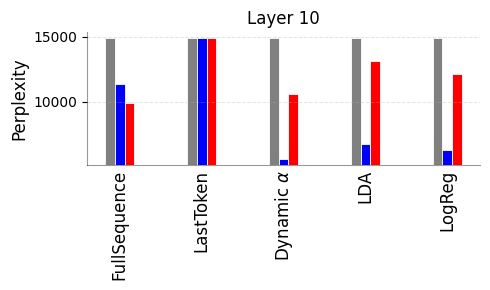

Model: meta-llama/Llama-3.2-3B-Instruct
Base perplexity: 224.48588814460854
Perplexities steering up: [203.0575971491009, 224.48588814460854, 210.93011407211932, 219.8273890905664, 217.33422935973965]
Perplexities steering down: [209.7607201391142, 224.48588814460854, 198.03416448518027, 194.95869282660487, 196.8921160755001]
5 5 5
5


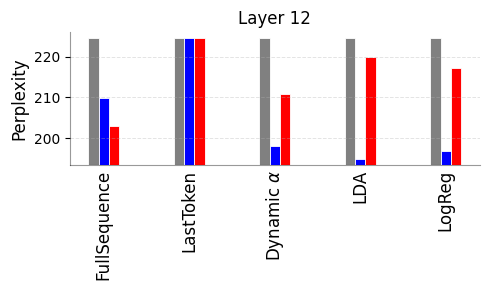

Model: google/gemma-2-2b
Base perplexity: 252.92059847339976
Perplexities steering up: [92.72839060719026, 252.92059847339976, 128.8467175836213, 162.2886597640699, 164.64047956374856]
Perplexities steering down: [138.12375331249564, 252.92059847339976, 199.94567246837434, 234.25641301136906, 228.34903543374784]
5 5 5
5


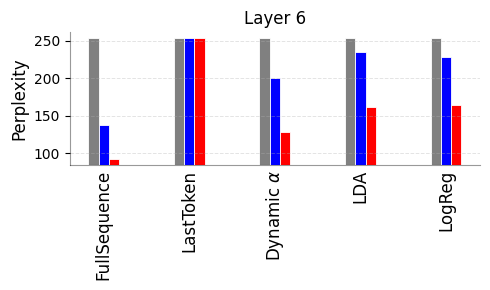

Model: meta-llama/Llama-3.2-3B
Base perplexity: 49.96371289324105
Perplexities steering up: [50.33833655080444, 49.96371289324105, 50.455318062885006, 50.337952896144266, 50.681225456039066]
Perplexities steering down: [52.432643133804696, 49.96371289324105, 49.955388561796994, 50.16848016702655, 49.72924915878052]
5 5 5
5


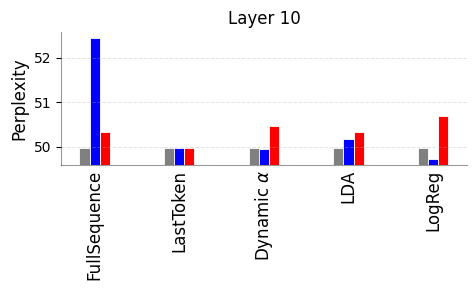

Model: Qwen/Qwen2.5-3B
Base perplexity: 62.92238035846269
Perplexities steering up: [64.16234912409467, 62.92238035846269, 64.31403307407594, 64.19466951184594, 65.64220316303677]
Perplexities steering down: [69.13942866934089, 62.92238035846269, 62.019220185304974, 62.09640020795463, 60.625414197142945]
5 5 5
5


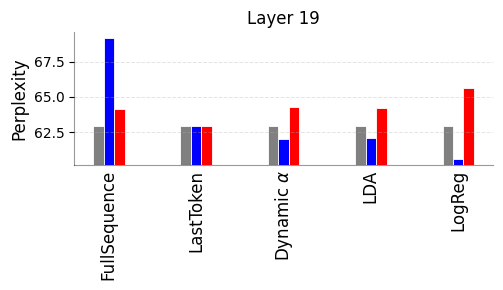

Model: Qwen/Qwen2.5-3B-Instruct
Base perplexity: 285.9073227453219
Perplexities steering up: [149.01587595751076, 75.01650899605954, 189.70832309179244, 218.18862103521448, 230.73044359699006]
Perplexities steering down: [415.997263556558, 75.01650899605954, 518.7015062057789, 414.87199635245037, 385.2606629388448]
5 5 5
5


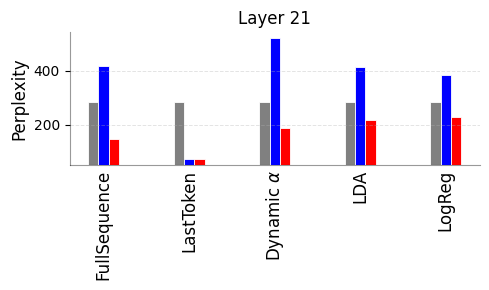

In [21]:
for model in models:
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    save_dir = os.path.join(output_dir, safe_model_name)
    with open(os.path.join(save_dir, "base_perplexity.json")) as f:
        base_perplexity = json.load(f)["base_perplexity"]

    
    # Load JSON
    with open(os.path.join(save_dir, "steered_perplexities.json")) as f:
    # with open(os.path.join(save_dir, "abladed_perplexities_pca.json")) as f:
        perplexities = json.load(f)

    
    save_dir = os.path.join(output_dir, 'last', safe_model_name)
    with open(os.path.join(save_dir, "steered_perplexities.json")) as f:
        perplexities_last = json.load(f)

    with open(os.path.join(save_dir, "steered_perplexities_classifier_euclidean.json")) as f:
        perplexities_classifier_euclidean = json.load(f)['adaptive']
    with open(os.path.join(save_dir, "steered_perplexities_classifier_n_n_euclidean.json")) as f:
        perplexities_classifier_n_euclidean = json.load(f)['adaptive']

    with open(os.path.join(save_dir, "steered_perplexities_classifier_lda_svd.json")) as f:
        perplexities_classifier_lda = json.load(f)['adaptive']
    with open(os.path.join(save_dir, "steered_perplexities_classifier_n_n_lda_svd.json")) as f:
        perplexities_classifier_n_lda = json.load(f)['adaptive']

    with open(os.path.join(save_dir, "steered_perplexities_classifier_linear_regression.json")) as f:
        perplexities_classifier_logreg = json.load(f)['adaptive']
    with open(os.path.join(save_dir, "steered_perplexities_classifier_n_n_linear_regression.json")) as f:
        perplexities_classifier_n_logreg = json.load(f)['adaptive']

    perplexities_up = []
    perplexities_down = []

    for i, layer in enumerate(model_steering_final[model]['layers'][:1]):
        alpha_up = model_steering_final[model]['alphas_up'][i]
        perp_up = get_perplexity(perplexities, alpha_up, layer)
        perplexities_up.append(perp_up)

        alpha_down = model_steering_final[model]['alphas_down'][i]
        perp_down = get_perplexity(perplexities, alpha_down, layer)
        perplexities_down.append(perp_down)

        alpha_up_last = model_steering_last_final[model]['alphas_up'][i]
        perp_up_last = get_perplexity(perplexities_last, alpha_up_last, layer)
        perplexities_up.append(perp_up_last)

        alpha_down_last = model_steering_last_final[model]['alphas_down'][i]
        perp_down_last = get_perplexity(perplexities_last, alpha_down_last, layer)
        perplexities_down.append(perp_down_last)

        perp_eucl = get_perplexity_other(perplexities_classifier_euclidean, layer)
        perplexities_up.append(perp_eucl)

        perp_n_eucl = get_perplexity_other(perplexities_classifier_n_euclidean, layer)
        perplexities_down.append(perp_n_eucl)

        perp_lda = get_perplexity_other(perplexities_classifier_lda, layer)
        perplexities_up.append(perp_lda)
        perp_n_lda = get_perplexity_other(perplexities_classifier_n_lda, layer)
        perplexities_down.append(perp_n_lda)

        perp_logreg = get_perplexity_other(perplexities_classifier_logreg, layer)
        perplexities_up.append(perp_logreg)
        perp_n_logreg = get_perplexity_other(perplexities_classifier_n_logreg, layer)
        perplexities_down.append(perp_n_logreg)

    print(f"Model: {model}")
    print(f"Base perplexity: {base_perplexity}")
    print(f"Perplexities steering up: {perplexities_up}")
    print(f"Perplexities steering down: {perplexities_down}")
    up_color = 'red'
    down_color = 'blue'
    base_col = 'grey'
    x_ticks = ['FullSequence', 'LastToken', r'Dynamic $\alpha$', 'LDA', 'LogReg']
    print(len(perplexities_up), len(perplexities_down), len(x_ticks))
    
    K = len(x_ticks)
    x = np.arange(1, K + 1, dtype=float)
    print(len(x))
    offset = 0.25  # spacing for 3 grouped boxplots

    plt.figure(figsize=(5, 3))

    
    perp_up = np.array(perplexities_up)
    perp_down = np.array(perplexities_down)
    perp_base = np.array([base_perplexity] * K)

    bar_width = 0.12
    # Base (right group)
    plt.bar(x - bar_width, perp_base, width=bar_width, color=base_col, edgecolor="white", linewidth=0.6)

    # Steering Down (middle group)
    plt.bar(x, perp_down, width=bar_width, color=down_color, edgecolor="white", linewidth=0.6)

    # Steering Up (left group)
    plt.bar(x + bar_width, perp_up, width=bar_width, color=up_color, edgecolor="white", linewidth=0.6)

    

    
    ax = plt.gca()  # get current axes

    # y-limit padding
    all_vals = np.concatenate([perp_up, perp_down, perp_base])
    pad = 0.05 * (all_vals.max() - all_vals.min())
    ylim = (all_vals.min() - pad, all_vals.max() + pad)
    ax.set_ylim(*ylim)
    ax.set_title(f'Layer {layer.split(".")[-1]}')

    # x ticks
    plt.xticks(x, x_ticks, rotation=90, fontsize=12)

    # grid
    plt.grid(axis="y", linestyle="--", alpha=0.35, linewidth=0.7)

    # spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.4)
    ax.spines["bottom"].set_alpha(0.4)

    # remove x ticks
    plt.tick_params(axis="x", length=0)

    # title + label
    # X ticks
    # plt.xticks(x, x_ticks, rotation=90, fontsize=12)
    # plt.yscale("log")
    plt.ylabel("Perplexity", fontsize=12)
    # plt.title(f"{model} ")
    plt.tight_layout()
    save_d = os.path.join("/home/fe/purelku/Desktop/Master_thesis", "perplexity_plots")
    os.makedirs(save_d, exist_ok=True)
    plt.savefig(os.path.join(save_d, f"{safe_model_name}_perplexity_comparison.svg"), format='svg',  bbox_inches="tight", dpi=300)

    plt.show()


